In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Loan Prediction Dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


## Handle Missing Values

In [3]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["Married"] = df["Married"].fillna(df["Married"].mode()[0])
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])
df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


## Visualizations

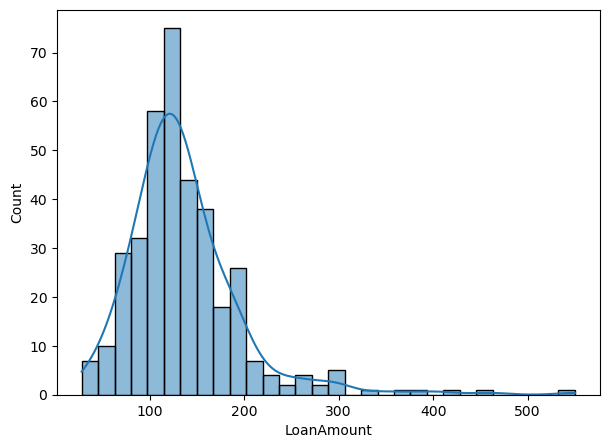

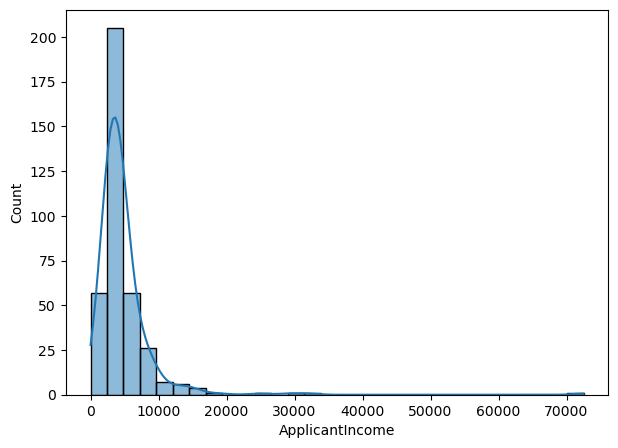

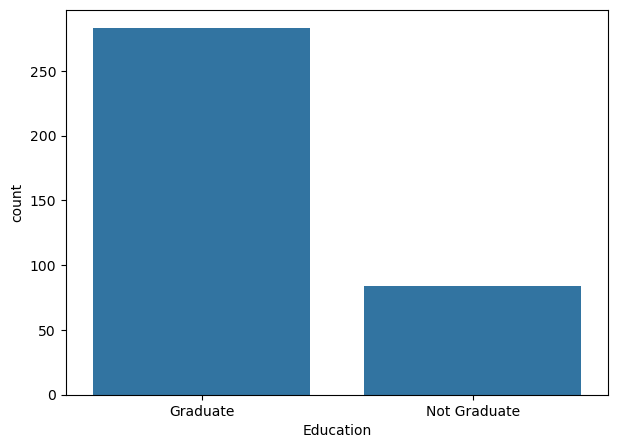

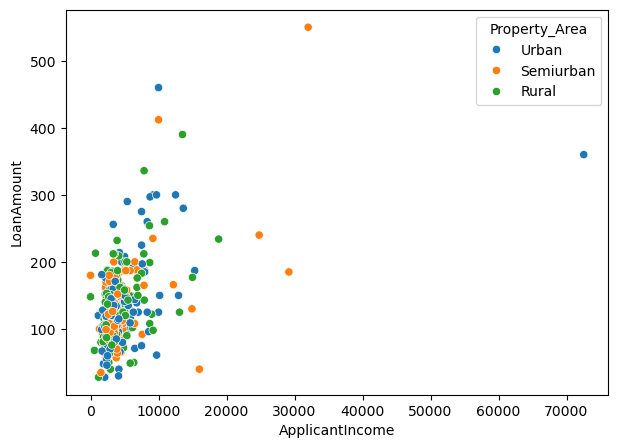

In [4]:
plt.figure(figsize=(7,5))
sns.histplot(df["LoanAmount"], bins=30, kde=True)
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df["ApplicantIncome"], bins=30, kde=True)
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(x="Education", data=df)
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(
    x="ApplicantIncome",
    y="LoanAmount",
    hue="Property_Area",
    data=df
)
plt.show()

## Data Encoding and Model Training

In [5]:
le = LabelEncoder()

df["Loan_ID"] = le.fit_transform(df["Loan_ID"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Dependents"] = le.fit_transform(df["Dependents"])
df["Education"] = le.fit_transform(df["Education"])
df["Self_Employed"] = le.fit_transform(df["Self_Employed"])
df["Property_Area"] = le.fit_transform(df["Property_Area"])

X = df.drop("LoanAmount", axis=1)

y = df["LoanAmount"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

predictions[:10]

array([125, 100, 125,  87, 187, 160, 100, 106, 125, 125])

## Accuracy and Confusion Matrix

Accuracy: 0.05405405405405406
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]]


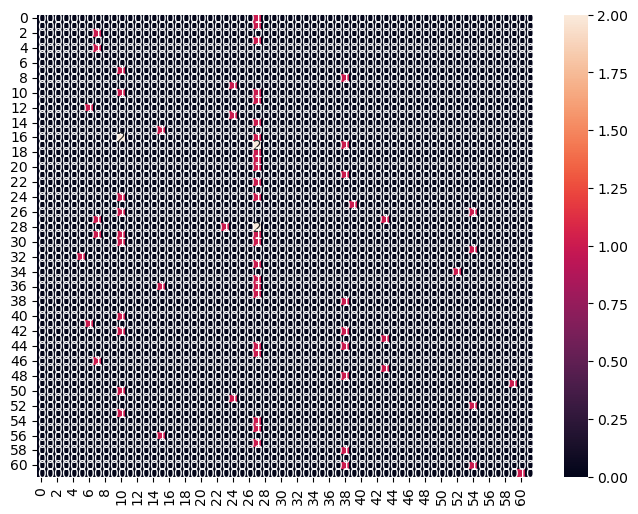

              precision    recall  f1-score   support

          50       0.00      0.00      0.00         1
          64       0.00      0.00      0.00         1
          70       0.00      0.00      0.00         1
          71       0.00      0.00      0.00         1
          75       0.00      0.00      0.00         1
          80       0.00      0.00      0.00         0
          87       0.00      0.00      0.00         0
          90       0.00      0.00      0.00         1
          92       0.00      0.00      0.00         1
          99       0.00      0.00      0.00         1
         100       0.08      0.50      0.14         2
         101       0.00      0.00      0.00         1
         102       0.00      0.00      0.00         1
         104       0.00      0.00      0.00         1
         105       0.00      0.00      0.00         1
         106       0.33      1.00      0.50         1
         108       0.00      0.00      0.00         3
         110       0.00    

In [6]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, predictions)

print(cm)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d")

plt.show()

print(classification_report(y_test, predictions))